# Grab VN - Simple EDA Notebook

This notebook reads the SQLite database, applies basic formatting, and runs a few quick EDA summaries.

In [5]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

In [6]:
DB_PATH = Path('grab_vn_case.db')
assert DB_PATH.exists(), f'Database not found: {DB_PATH.resolve()}'

conn = sqlite3.connect(DB_PATH)

users = pd.read_sql_query('SELECT * FROM users', conn)
weather_daily = pd.read_sql_query('SELECT * FROM weather_daily', conn)
transactions = pd.read_sql_query('SELECT * FROM transactions', conn)
daily_gmv_summary = pd.read_sql_query('SELECT * FROM daily_gmv_summary', conn)

conn.close()

print('Loaded tables:')
print('users:', users.shape)
print('weather_daily:', weather_daily.shape)
print('transactions:', transactions.shape)
print('daily_gmv_summary:', daily_gmv_summary.shape)

Loaded tables:
users: (11800, 5)
weather_daily: (294, 4)
transactions: (182313, 13)
daily_gmv_summary: (2642, 11)


In [4]:
# display head of each table
print('\nusers head:')
display(users.head())
print('\nweather_daily head:')
display(weather_daily.head())
print('\ntransactions head:')
display(transactions.head())
print('\ndaily_gmv_summary head:')
display(daily_gmv_summary.head())


users head:


,user_id,city,payment_preference,user_segment,registration_date
0,1,Ho Chi Minh City,Cash,Regular,2023-08-18
1,2,Ho Chi Minh City,ZaloPay,High Value,2023-08-03
2,3,Ho Chi Minh City,Cash,Voucher Hunter,2023-09-06
3,4,Ho Chi Minh City,Cash,Voucher Hunter,2023-07-25
4,5,Ho Chi Minh City,Cash,Regular,2022-07-29



weather_daily head:


,date,city,rainfall_mm,rain_category
0,2024-01-01,Ho Chi Minh City,1.6,None
1,2024-01-01,Da Nang,5.3,Light
2,2024-01-01,Hanoi,1.7,None
3,2024-01-02,Ho Chi Minh City,1.8,None
4,2024-01-02,Da Nang,5.3,Light



transactions head:


,transaction_id,date,week_number,period,city,service_type,user_id,payment_type,gross_gmv_k_vnd,discount_k_vnd,net_gmv_k_vnd,voucher_applied,rainfall_mm
0,1,2024-01-01,1,Pre-Promo,Ho Chi Minh City,GrabBike,2883,Card,35.53,0.0,35.53,0,1.6
1,2,2024-01-01,1,Pre-Promo,Ho Chi Minh City,GrabBike,5904,Cash,36.74,0.0,36.74,0,1.6
2,3,2024-01-01,1,Pre-Promo,Ho Chi Minh City,GrabBike,1193,Cash,44.65,0.0,44.65,0,1.6
3,4,2024-01-01,1,Pre-Promo,Ho Chi Minh City,GrabBike,3622,ZaloPay,38.32,0.0,38.32,0,1.6
4,5,2024-01-01,1,Pre-Promo,Ho Chi Minh City,GrabBike,5869,Cash,28.52,0.0,28.52,0,1.6



daily_gmv_summary head:


,date,week_number,period,city,service_type,payment_type,net_gmv_k_vnd,gross_gmv_k_vnd,total_discount_k_vnd,n_transactions,n_voucher_redemptions
0,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Card,332.00,332.00,0.0,9,0
1,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Cash,1832.92,1832.92,0.0,51,0
2,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,ZaloPay,632.41,632.41,0.0,17,0
3,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Card,152.75,152.75,0.0,1,0
4,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Cash,1895.53,1895.53,0.0,14,0


In [5]:
# Basic formatting
users['registration_date'] = pd.to_datetime(users['registration_date'], errors='coerce')
weather_daily['date'] = pd.to_datetime(weather_daily['date'], errors='coerce')
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')
daily_gmv_summary['date'] = pd.to_datetime(daily_gmv_summary['date'], errors='coerce')


daily_gmv_summary['net_gmv_m_vnd'] = daily_gmv_summary['net_gmv_k_vnd'] / 1000.0

quality = pd.DataFrame([
    {
        'table': 'users',
        'rows': len(users),
        'missing_cells': int(users.isna().sum().sum()),
        'duplicate_user_id': int(users['user_id'].duplicated().sum())
    },
    {
        'table': 'weather_daily',
        'rows': len(weather_daily),
        'missing_cells': int(weather_daily.isna().sum().sum()),
        'duplicate_user_id': None
    },
    {
        'table': 'transactions',
        'rows': len(transactions),
        'missing_cells': int(transactions.isna().sum().sum()),
        'duplicate_user_id': int(transactions['transaction_id'].duplicated().sum())
    },
    {
        'table': 'daily_gmv_summary',
        'rows': len(daily_gmv_summary),
        'missing_cells': int(daily_gmv_summary.isna().sum().sum()),
        'duplicate_user_id': None
    }
])

quality

,table,rows,missing_cells,duplicate_user_id
0,users,11800,0,0.0
1,weather_daily,294,0,NaN
2,transactions,182313,0,0.0
3,daily_gmv_summary,2642,0,NaN


In [6]:
# check if daily_gmv_summary is correct by comparing with transactions
group_by_cols = ['date','service_type','city','payment_type']
transactions['date'] = pd.to_datetime(transactions['date'])
gmv_summary_dummy = transactions.groupby(group_by_cols)['gross_gmv_k_vnd'].sum().reset_index()
gmv_summary_dummy.columns = group_by_cols + ['gmv_from_transactions']
gmv_comparison = pd.merge(daily_gmv_summary, gmv_summary_dummy, on=group_by_cols)
gmv_comparison['gmv_diff'] = gmv_comparison['gross_gmv_k_vnd'] - gmv_comparison['gmv_from_transactions']
print('\nGMV comparison:')
display(gmv_comparison.head())


GMV comparison:


,date,week_number,period,city,service_type,payment_type,net_gmv_k_vnd,gross_gmv_k_vnd,total_discount_k_vnd,n_transactions,n_voucher_redemptions,net_gmv_m_vnd,gmv_from_transactions,gmv_diff
0,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Card,332.00,332.00,0.0,9,0,0.33200,332.00,0.0
1,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Cash,1832.92,1832.92,0.0,51,0,1.83292,1832.92,0.0
2,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,ZaloPay,632.41,632.41,0.0,17,0,0.63241,632.41,0.0
3,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Card,152.75,152.75,0.0,1,0,0.15275,152.75,0.0
4,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Cash,1895.53,1895.53,0.0,14,0,1.89553,1895.53,0.0


In [7]:
daily_gmv_summary

,date,week_number,period,city,service_type,payment_type,net_gmv_k_vnd,gross_gmv_k_vnd,total_discount_k_vnd,n_transactions,n_voucher_redemptions,net_gmv_m_vnd
0,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Card,332.00,332.00,0.0,9,0,0.33200
1,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Cash,1832.92,1832.92,0.0,51,0,1.83292
2,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,ZaloPay,632.41,632.41,0.0,17,0,0.63241
3,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Card,152.75,152.75,0.0,1,0,0.15275
4,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Cash,1895.53,1895.53,0.0,14,0,1.89553
...,...,...,...,...,...,...,...,...,...,...,...,...
2637,2024-04-07,14,Post-Promo,Ho Chi Minh City,GrabCar,Cash,6902.77,6902.77,0.0,54,0,6.90277
2638,2024-04-07,14,Post-Promo,Ho Chi Minh City,GrabCar,ZaloPay,4528.40,4528.40,0.0,36,0,4.52840
2639,2024-04-07,14,Post-Promo,Ho Chi Minh City,GrabFood,Card,19849.06,19849.06,0.0,121,0,19.84906
2640,2024-04-07,14,Post-Promo,Ho Chi Minh City,GrabFood,Cash,50761.80,50761.80,0.0,306,0,50.76180


In [9]:
# Basic EDA summary
summary_by_period_city = (
    transactions
    .groupby(['period', 'city'], as_index=False)
    .agg(
        n_transactions=('transaction_id', 'count'),
        net_gmv_k_vnd=('net_gmv_k_vnd', 'sum'),
        gross_gmv_m_vnd=('gross_gmv_k_vnd', 'sum'),
        voucher_redemption_rate=('voucher_applied', 'mean')
    )
    .sort_values(['period', 'city'])
)

summary_by_period_city

,period,city,n_transactions,net_gmv_k_vnd,gross_gmv_m_vnd,voucher_redemption_rate
0,Post-Promo,Da Nang,3306,373170.04,373170.04,0.000000
1,Post-Promo,Hanoi,8242,917570.84,917570.84,0.000000
2,Post-Promo,Ho Chi Minh City,10539,1198175.93,1198175.93,0.000000
3,Pre-Promo,Da Nang,9951,1127543.48,1127543.48,0.000000
4,Pre-Promo,Hanoi,23610,2635188.37,2635188.37,0.000000
5,Pre-Promo,Ho Chi Minh City,36149,4140233.94,4140233.94,0.000000
6,Promo,Da Nang,12006,1557579.90,1557579.90,0.000000
7,Promo,Hanoi,24008,2656926.28,2656926.28,0.000000
8,Promo,Ho Chi Minh City,54502,6213116.44,7386069.08,0.642453


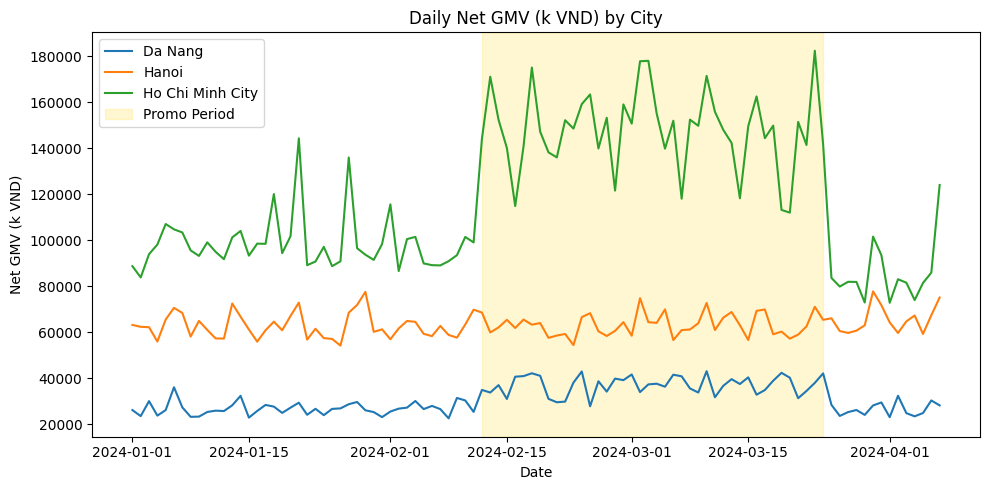

In [16]:
# Chart: Daily net GMV by city with highlighted promo period
plot_df = (
    daily_gmv_summary
    .groupby(['date', 'city'], as_index=False)['net_gmv_k_vnd']
    .sum()
    .sort_values('date')
)

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')

plt.figure(figsize=(10, 5))
for city, sub in plot_df.groupby('city'):
    plt.plot(sub['date'], sub['net_gmv_k_vnd'], label=city)

plt.axvspan(
    promo_start,
    promo_end,
    color='gold',
    alpha=0.18,
    label='Promo Period'
)

plt.title('Daily Net GMV (k VND) by City')
plt.xlabel('Date')
plt.ylabel('Net GMV (k VND)')
plt.legend()
plt.tight_layout()
plt.show()

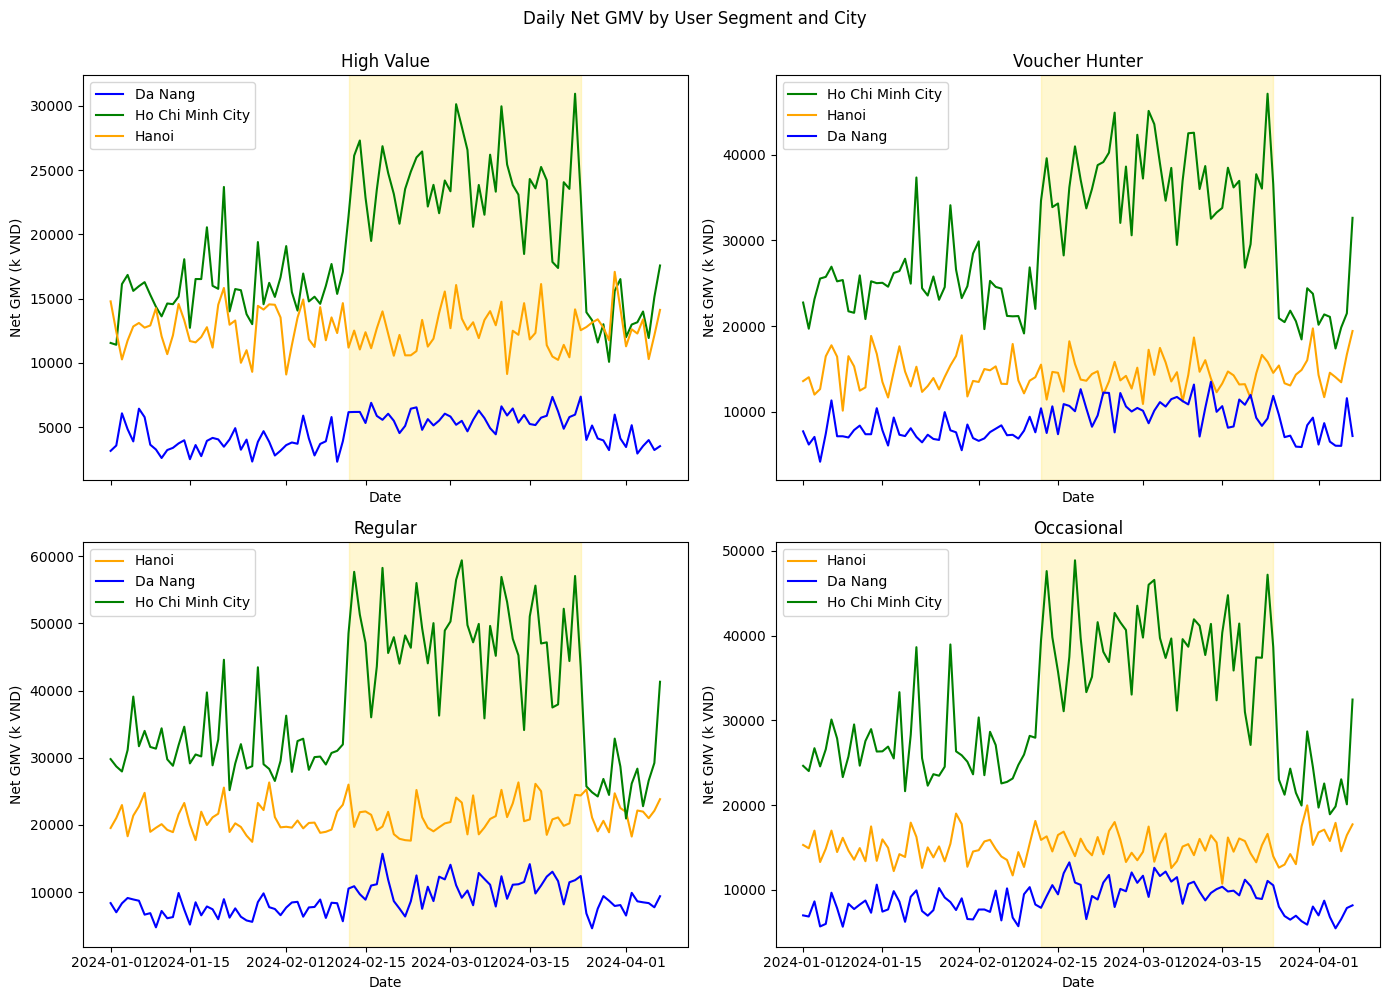

In [17]:
# Chart: daily net GMV by user segment AND city with highlighted promo period
tx_segment = transactions.merge(
    users[['user_id', 'user_segment']],
    on='user_id',
    how='left'
)

segment_city_plot = (
    tx_segment
    .groupby(['date', 'user_segment', 'city'], as_index=False)['net_gmv_k_vnd']
    .sum()
    .sort_values('date')
)

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')

segments = segment_city_plot['user_segment'].dropna().unique()
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    sharex=True,
    sharey=False,
)

axes = axes.flatten()
colors = {'Da Nang': 'blue', 'Hanoi': 'orange', 'Ho Chi Minh City': 'green'}

for ax, segment in zip(axes, segments):
    segment_data = segment_city_plot[
        segment_city_plot['user_segment'] == segment
    ]
    for city in segment_data['city'].unique():
        city_data = segment_data[segment_data['city'] == city]
        ax.plot(
            city_data['date'],
            city_data['net_gmv_k_vnd'],
            label=city,
            color=colors.get(city, 'gray')
        )
    ax.axvspan(promo_start, promo_end, color='gold', alpha=0.18)
    ax.set_title(str(segment))
    ax.set_xlabel('Date')
    ax.set_ylabel('Net GMV (k VND)')
    ax.legend()

for ax in axes[len(segments):]:
    ax.axis('off')

fig.suptitle('Daily Net GMV by User Segment and City', y=0.995)
fig.tight_layout()
plt.show()

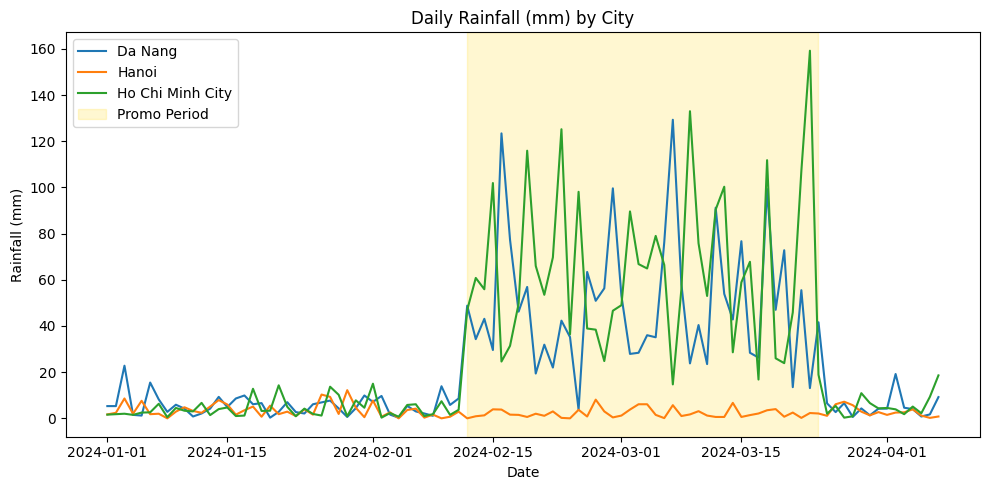

In [8]:
# Chart: daily rainfall by city with highlighted promo period
rain_plot = weather_daily.copy()
rain_plot['date'] = pd.to_datetime(rain_plot['date'], errors='coerce')
rain_plot = rain_plot.sort_values(['city', 'date'])

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')

plt.figure(figsize=(10, 5))
for city, sub in rain_plot.groupby('city'):
    plt.plot(sub['date'], sub['rainfall_mm'], label=city)

plt.axvspan(
    promo_start,
    promo_end,
    color='gold',
    alpha=0.18,
    label='Promo Period'
)

plt.title('Daily Rainfall (mm) by City')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.tight_layout()
plt.show()

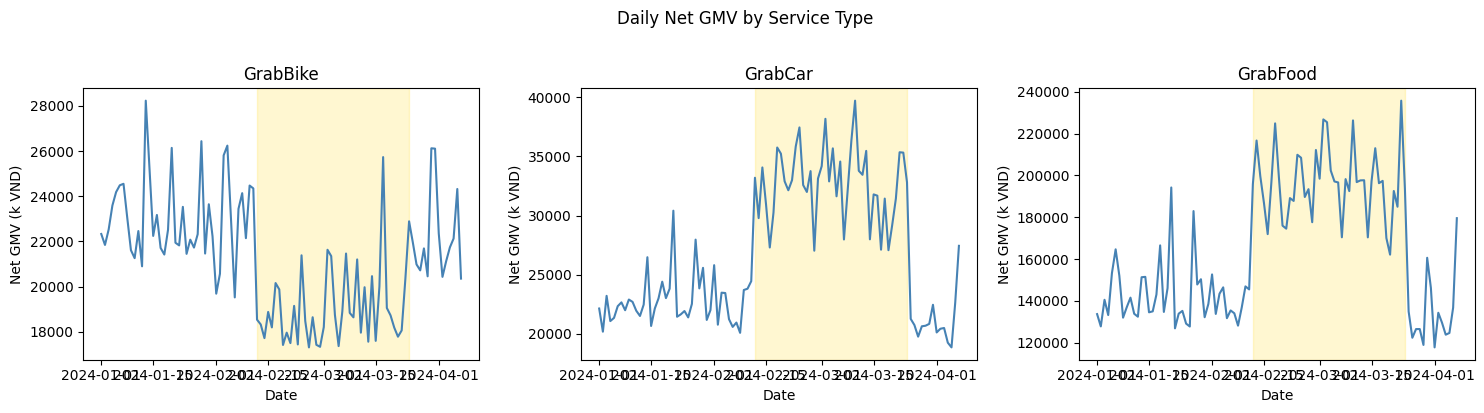

In [10]:
# Chart: daily net GMV by service type with highlighted promo period
service_plot = (
    daily_gmv_summary.copy()
)
service_plot['date'] = pd.to_datetime(service_plot['date'], errors='coerce')
service_plot = (
    service_plot
    .groupby(['date', 'service_type'], as_index=False)['net_gmv_k_vnd']
    .sum()
    .sort_values('date')
)

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')

service_order = ['GrabBike', 'GrabCar', 'GrabFood']
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4),
    sharex=True,
    sharey=False,
)

for ax, service_type in zip(axes, service_order):
    sub = service_plot[service_plot['service_type'] == service_type]
    ax.plot(sub['date'], sub['net_gmv_k_vnd'], color='steelblue')
    ax.axvspan(promo_start, promo_end, color='gold', alpha=0.18)
    ax.set_title(service_type)
    ax.set_xlabel('Date')
    ax.set_ylabel('Net GMV (k VND)')

fig.suptitle('Daily Net GMV by Service Type', y=1.02)
fig.tight_layout()
plt.show()

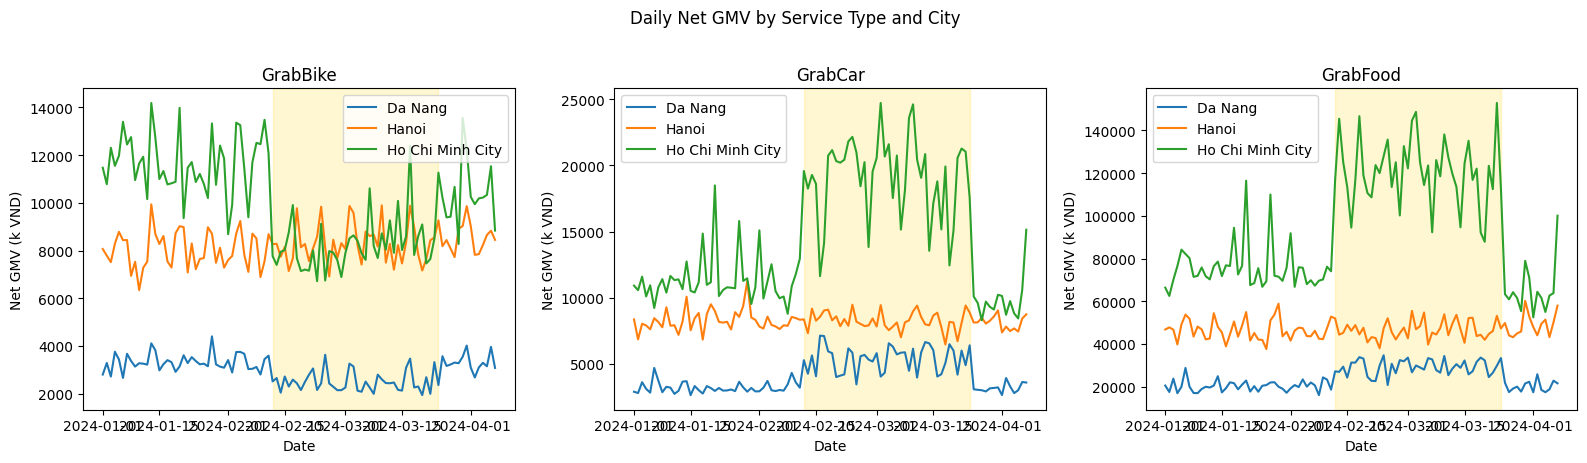

In [13]:
# Chart: daily net GMV by service type, colored by city, with highlighted promo period
service_city_plot = (
    daily_gmv_summary.copy()
)
service_city_plot['date'] = pd.to_datetime(service_city_plot['date'], errors='coerce')
service_city_plot = (
    service_city_plot
    .groupby(['date', 'service_type', 'city'], as_index=False)['net_gmv_k_vnd']
    .sum()
    .sort_values('date')
)

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')

service_order = ['GrabBike', 'GrabCar', 'GrabFood']
city_colors = {
    'Da Nang': 'tab:blue',
    'Hanoi': 'tab:orange',
    'Ho Chi Minh City': 'tab:green',
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 4.5),
    sharex=True,
    sharey=False,
)

for ax, service_type in zip(axes, service_order):
    service_data = service_city_plot[service_city_plot['service_type'] == service_type]
    for city_name in ['Da Nang', 'Hanoi', 'Ho Chi Minh City']:
        city_data = service_data[service_data['city'] == city_name]
        ax.plot(
            city_data['date'],
            city_data['net_gmv_k_vnd'],
            label=city_name,
            color=city_colors.get(city_name, 'gray')
        )
    ax.axvspan(promo_start, promo_end, color='gold', alpha=0.18)
    ax.set_title(service_type)
    ax.set_xlabel('Date')
    ax.set_ylabel('Net GMV (k VND)')
    ax.legend()

fig.suptitle('Daily Net GMV by Service Type and City', y=1.02)
fig.tight_layout()
plt.show()